In [5]:
import pandas as pd

# --- Load & label ---
group = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/interaction_type_bout.csv')
group['condition'] = 'group-housed'

iso = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/interaction_type_bout.csv')
iso['condition'] = 'socially-isolated'

df = pd.concat([group, iso], ignore_index=True)

# --- Helper: merge overlapping intervals and return total covered frames ---
def covered_frames(intervals):
    """Given a list of (start, end) tuples, return total frames covered after merging overlaps."""
    merged = []
    for start, end in sorted(intervals):
        if merged and start <= merged[-1][1]:
            merged[-1] = (merged[-1][0], max(merged[-1][1], end))
        else:
            merged.append([start, end])
    return sum(e - s + 1 for s, e in merged)

# --- Melt so each larva gets its own rows ---
# fps = 1, recording = 3600 s
TOTAL_SECONDS = 3600

df_melted = pd.melt(
    df,
    id_vars=['file', 'condition', 'start_frame', 'end_frame'],
    value_vars=['track_1', 'track_2'],
    value_name='larva'
).drop(columns='variable')

# --- Per larva: merge overlapping bouts, sum true covered frames ---
proportion_overall = (
    df_melted
    .groupby(['condition', 'file', 'larva'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
proportion_overall['proportion'] = proportion_overall['contact_seconds'] / TOTAL_SECONDS

proportion_overall.head(10)


,condition,file,larva,contact_seconds,proportion
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,346,0.096111
1,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,201,0.055833
2,group-housed,2025-02-24_11-59-11_td14.tracks.feather,2,223,0.061944
3,group-housed,2025-02-24_11-59-11_td14.tracks.feather,3,188,0.052222
4,group-housed,2025-02-24_11-59-11_td14.tracks.feather,4,138,0.038333
5,group-housed,2025-02-24_11-59-11_td14.tracks.feather,5,203,0.056389
6,group-housed,2025-02-24_11-59-11_td14.tracks.feather,6,211,0.058611
7,group-housed,2025-02-24_11-59-11_td14.tracks.feather,7,341,0.094722
8,group-housed,2025-02-24_11-59-11_td14.tracks.feather,8,188,0.052222
9,group-housed,2025-02-24_11-59-11_td14.tracks.feather,9,261,0.072500


In [6]:
# --- Proportion of time in contact binned into 600-second intervals ---
# fps = 1 so start_frame == second; assign each bout to the bin its start_frame falls in
BIN_SIZE = 600
TOTAL_SECONDS = 3600

df['time_bin'] = (df['start_frame'] // BIN_SIZE) * BIN_SIZE  # bin labels: 0, 600, 1200, 1800, 2400, 3000

df_melted_bins = pd.melt(
    df,
    id_vars=['file', 'condition', 'start_frame', 'end_frame', 'time_bin'],
    value_vars=['track_1', 'track_2'],
    value_name='larva'
).drop(columns='variable')

# Per larva per bin: merge overlapping bouts within each bin, sum true covered frames
proportion_binned = (
    df_melted_bins
    .groupby(['condition', 'file', 'larva', 'time_bin'])
    .apply(lambda g: covered_frames(zip(g['start_frame'], g['end_frame'])))
    .reset_index(name='contact_seconds')
)
proportion_binned['proportion'] = proportion_binned['contact_seconds'] / BIN_SIZE

proportion_binned.head(10)


,condition,file,larva,time_bin,contact_seconds,proportion
0,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,0,63,0.105000
1,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,600,135,0.225000
2,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,1200,60,0.100000
3,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,1800,9,0.015000
4,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,2400,45,0.075000
5,group-housed,2025-02-24_11-59-11_td14.tracks.feather,0,3000,34,0.056667
6,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,0,64,0.106667
7,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,600,60,0.100000
8,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,1200,2,0.003333
9,group-housed,2025-02-24_11-59-11_td14.tracks.feather,1,1800,16,0.026667


Mann-Whitney U = 92.0, p = 0.0017


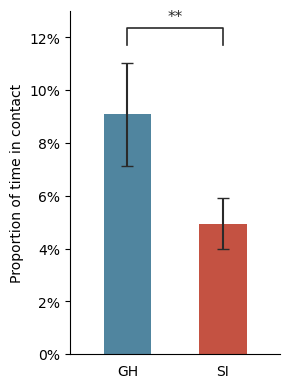

In [7]:
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

COLORS = {'group-housed': '#50859f', 'socially-isolated': '#c45242'}
LABELS = {'group-housed': 'GH', 'socially-isolated': 'SI'}
CONDITIONS = ['group-housed', 'socially-isolated']  # GH first

# Average across larvae per video
per_video_overall = (
    proportion_overall
    .groupby(['condition', 'file'])['proportion']
    .mean()
    .reset_index()
)

gh_vals = per_video_overall[per_video_overall['condition'] == 'group-housed']['proportion'].values
si_vals = per_video_overall[per_video_overall['condition'] == 'socially-isolated']['proportion'].values

stat, p = mannwhitneyu(gh_vals, si_vals, alternative='two-sided')
print(f'Mann-Whitney U = {stat:.1f}, p = {p:.4f}')

def p_to_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

fig, ax = plt.subplots(figsize=(3, 4))

for i, cond in enumerate(CONDITIONS):
    vals = per_video_overall[per_video_overall['condition'] == cond]['proportion'].values
    mean = vals.mean()
    ci   = 1.96 * vals.std(ddof=1) / np.sqrt(len(vals))
    ax.bar(i, mean, width=0.5, color=COLORS[cond], zorder=2, clip_on=False)
    ax.errorbar(i, mean, yerr=ci, color='#2a2a2a', capsize=4,
                linewidth=1.5, zorder=3, linestyle='none')

# Significance bracket
y_max = max(
    per_video_overall[per_video_overall['condition'] == c]['proportion'].mean() +
    1.96 * per_video_overall[per_video_overall['condition'] == c]['proportion'].std(ddof=1) /
    np.sqrt(len(per_video_overall[per_video_overall['condition'] == c]))
    for c in CONDITIONS
)
y_bracket = y_max * 1.12
y_tip     = y_max * 1.06
stars     = p_to_stars(p)

ax.plot([0, 0, 1, 1], [y_tip, y_bracket, y_bracket, y_tip],
        color='#2a2a2a', linewidth=1.2)
ax.text(0.5, y_bracket * 1.01, stars, ha='center', va='bottom',
        fontsize=11 if stars != 'ns' else 9, color='#2a2a2a')

ax.set_xticks([0, 1])
ax.set_xticklabels([LABELS[c] for c in CONDITIONS])
ax.set_ylabel('Proportion of time in contact')
ax.set_xlim(-0.6, 1.6)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(bottom=False)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/GROUP-ISO/contact_proportion_overall.pdf', bbox_inches='tight')
plt.show()


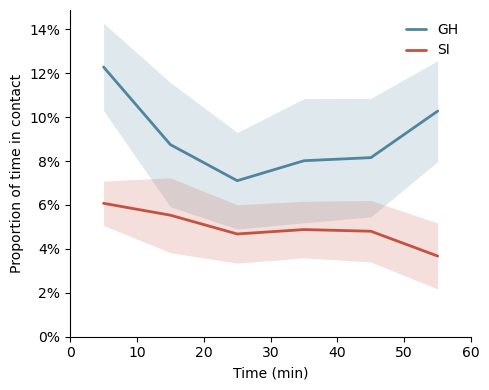

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

COLORS = {'group-housed': '#50859f', 'socially-isolated': '#c45242'}
LABELS = {'group-housed': 'GH', 'socially-isolated': 'SI'}
CONDITIONS = ['group-housed', 'socially-isolated']
BIN_SIZE = 600

# Fill zeros for larvae with no contact in a bin, then average per video
all_larvae = proportion_binned[['condition', 'file', 'larva']].drop_duplicates()
all_bins   = pd.DataFrame({'time_bin': sorted(proportion_binned['time_bin'].unique())})
full_index = all_larvae.merge(all_bins, how='cross')

proportion_binned_full = (
    full_index
    .merge(proportion_binned, on=['condition', 'file', 'larva', 'time_bin'], how='left')
    .fillna({'contact_seconds': 0, 'proportion': 0})
)

per_video_binned = (
    proportion_binned_full
    .groupby(['condition', 'file', 'time_bin'])['proportion']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(5, 4))

for cond in CONDITIONS:
    data  = per_video_binned[per_video_binned['condition'] == cond]
    stats = (
        data.groupby('time_bin')['proportion']
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    stats['ci'] = 1.96 * stats['std'] / np.sqrt(stats['count'])
    x = (stats['time_bin'] + BIN_SIZE / 2) / 60  # bin midpoint in minutes

    ax.plot(x, stats['mean'], color=COLORS[cond], linewidth=2,
            label=LABELS[cond], solid_capstyle='round')
    ax.fill_between(x,
                    stats['mean'] - stats['ci'],
                    stats['mean'] + stats['ci'],
                    color=COLORS[cond], alpha=0.18, linewidth=0)

ax.set_xlabel('Time (min)')
ax.set_ylabel('Proportion of time in contact')
ax.set_xlim(0, 60)
ax.set_ylim(0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False, handlelength=1.5)
plt.tight_layout()
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/FIGURE-2/GROUP-ISO/contact_proportion_over_time.pdf', bbox_inches='tight')
plt.show()
